In [3]:
from fontTools.ttLib import TTFont

print("hello")

hello


In [5]:
from BGN_LNG.Pricers.volcorr import VolCorr
import numpy as np

a = VolCorr(["TTF"], [0.1, 0.1], [0, 1], np.array([[1, 0.2], [0.2, 1]]))
print("VolCorr as been read")

VolCorr as been read


In [65]:
import pandas as pd
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\market_data\\TTF_history_Dec24_Dec25.csv"
df = pd.read_csv(csv_file_path)

In [34]:
import pandas as pd
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\market_data\\Brent_history_Dec20_Dec25.csv"
df = pd.read_csv(csv_file_path)

In [66]:
from datetime import date
_dict_month_to_int = { "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12}

columns_to_keep = ["Curve", "Effective Date", "Contract Start", "Value"]
df_filt = df[columns_to_keep].copy()

def change_curve_name(name):
    if name == "Dutch TTF Natural Gas Futures Forward":
        return "TTF"
    elif name== "ICE Brent Forward":
        return "Brent"
    return name

def get_tenor_from_row(row):
    today_date_str = row["Effective Date"]
    _today_date_str = today_date_str.split(" ")[1:]
    year, month, day = int(_today_date_str[2]), _today_date_str[0], _today_date_str[1]
    month_int_today = _dict_month_to_int[month]

    contract_start_date_str = row["Contract Start"]
    _contract_start_date_str = contract_start_date_str.split(" ")[1:]
    tenor_year, tenor_month, tenor_day = int(_contract_start_date_str[2]), _contract_start_date_str[0], _contract_start_date_str[1]
    month_int_tenor = _dict_month_to_int[tenor_month]

    M_theo = int((tenor_year - year) * 12 + month_int_tenor - month_int_today)
    return M_theo

def get_today(today_str):
    # today_date_str = row["Effective Date"]
    _today_date_str = today_str.split(" ")[1:]
    year, month, day = int(_today_date_str[2]), _today_date_str[0], int(_today_date_str[1])
    month_int_today = _dict_month_to_int[month]

    return date(year, month_int_today, day)

df_filt["Tenor"] = df_filt.apply(get_tenor_from_row, axis=1)
df_filt["Curve"] = df_filt["Curve"].apply(change_curve_name)
df_filt["Effective Date"] = df_filt["Effective Date"].apply(get_today)
df_filt.set_index("Effective Date", inplace=True)
df_filt.index.name = None



In [67]:

df_filt

,Curve,Contract Start,Value,Tenor
2024-12-04,TTF,Wednesday January 01 2025,47.046,1
2024-12-04,TTF,Thursday January 01 2026,41.638,13
2024-12-04,TTF,Friday January 01 2027,34.372,25
2024-12-04,TTF,Saturday February 01 2025,47.074,2
2024-12-04,TTF,Sunday February 01 2026,40.838,14
...,...,...,...,...
2025-12-05,TTF,Friday October 01 2027,25.072,22
2025-12-05,TTF,Sunday November 01 2026,27.403,11
2025-12-05,TTF,Monday November 01 2027,25.811,23
2025-12-05,TTF,Tuesday December 01 2026,27.673,12


In [68]:
# RUN THIS FOR PROCESSING TTF FORWARD CURVE FROM ZEMA UGLY FORMAT
from datetime import date
tenor_columns = ["M" + str(i) for i in range(1, 25)]
# Defining TTF forward curve values
start_date = date(2024, 12, 4)  # For TTF

date_index = df_filt.index.unique()
tenor_to_values = {t: [] for t in tenor_columns}

for _date in date_index:
    day_df = df_filt.loc[_date]
    if len(day_df[day_df["Tenor"] == 1].Value.values) == 0:  # No M1 available, tenors shifted by 1
        i_shift = 1
    else:
        i_shift = 0
    for T in range(1, 25):
        _value = day_df[day_df["Tenor"] == (T+i_shift)].Value.values[0]
        tenor_to_values["M"+str(T)].append(_value)
final_df_ttf = pd.DataFrame(data=tenor_to_values)
final_df_ttf.set_index(date_index, inplace=True)
print(final_df_ttf)

                M1      M2      M3      M4      M5      M6      M7      M8  \
2024-12-04  47.046  47.074  46.749  45.948  45.275  45.000  44.588  44.333   
2024-12-05  46.551  46.596  46.344  45.538  44.901  44.643  44.251  43.976   
2024-12-06  46.480  46.531  46.321  45.499  44.885  44.645  44.266  44.001   
2024-12-09  44.855  44.926  44.699  43.955  43.380  43.195  42.885  42.670   
2024-12-10  45.552  45.594  45.368  44.595  44.063  43.853  43.590  43.418   
...            ...     ...     ...     ...     ...     ...     ...     ...   
2025-12-01  28.227  28.286  28.004  27.191  26.859  26.874  26.927  27.022   
2025-12-02  28.050  28.124  27.840  27.077  26.754  26.788  26.854  26.939   
2025-12-03  28.206  28.298  28.045  27.312  27.010  27.029  27.070  27.167   
2025-12-04  27.088  27.209  27.021  26.431  26.190  26.233  26.274  26.364   
2025-12-05  27.266  27.366  27.192  26.572  26.312  26.319  26.354  26.463   

                M9     M10  ...     M15     M16     M17     M18

In [31]:
# final_df_ttf.to_csv("C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\market_data\\TTF_forward_curve_processed.csv")

<Axes: >

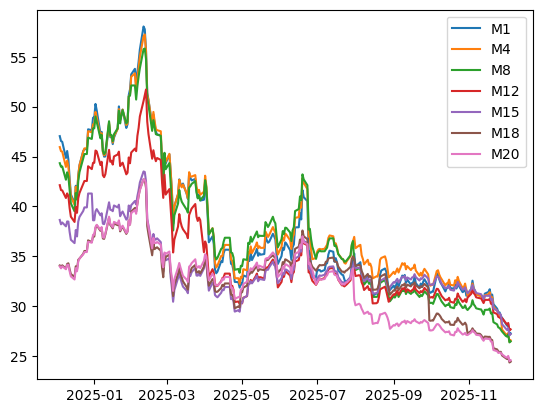

In [69]:
import matplotlib.pyplot as plt
final_df_ttf[["M1", "M4", "M8", "M12", "M15", "M18", "M20"]].plot()

In [56]:
# RUN THIS FOR PROCESSING BRENT FORWARD CURVE FROM ZEMA UGLY FORMAT
from datetime import date
tenor_columns = ["M" + str(i) for i in range(1, 24)]
# Defining BRENT forward curve values
start_date = date(2020, 12, 8)  # For BRENT

date_index = df_filt.index.unique()
tenor_to_values = {t: [] for t in tenor_columns}

for _date in date_index:
    day_df = df_filt.loc[_date]
    if len(day_df[day_df["Tenor"] == 2].Value.values) == 0:  # No M2 available, tenors shifted by 1
        i_shift = 2
    else:
        i_shift = 1
    for T in range(1, 24):
        try:
            _value = day_df[day_df["Tenor"] == (T+i_shift)].Value.values[0]
            tenor_to_values["M"+str(T)].append(_value)
        except:
            a = 1

final_df_brent = pd.DataFrame(data=tenor_to_values)
final_df_brent.set_index(date_index, inplace=True)
print(final_df_brent)

               M1     M2     M3     M4     M5     M6     M7     M8     M9  \
2020-12-08  48.84  48.81  48.83  48.86  48.86  48.81  48.79  48.73  48.64   
2020-12-09  48.86  48.77  48.74  48.74  48.73  48.66  48.63  48.57  48.48   
2020-12-10  50.25  50.12  50.04  49.98  49.92  49.80  49.71  49.60  49.48   
2020-12-11  49.97  49.90  49.84  49.79  49.73  49.62  49.53  49.42  49.29   
2020-12-15  50.76  50.71  50.66  50.62  50.56  50.43  50.34  50.22  50.10   
...           ...    ...    ...    ...    ...    ...    ...    ...    ...   
2025-12-01  63.17  62.78  62.54  62.45  62.44  62.43  62.41  62.38  62.36   
2025-12-02  62.45  62.05  61.82  61.73  61.72  61.72  61.70  61.68  61.67   
2025-12-03  62.67  62.28  62.06  61.97  61.94  61.92  61.89  61.85  61.82   
2025-12-04  63.26  62.86  62.61  62.48  62.42  62.37  62.31  62.26  62.20   
2025-12-05  63.75  63.39  63.14  63.00  62.92  62.86  62.78  62.70  62.63   

              M10  ...    M14    M15    M16    M17    M18    M19    M20  \


In [57]:
# {t: len(v) for t, v in tenor_to_values.items()}

# final_df_brent.to_csv("C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\market_data\\BRENT_forward_curve_processed.csv")

<Axes: >

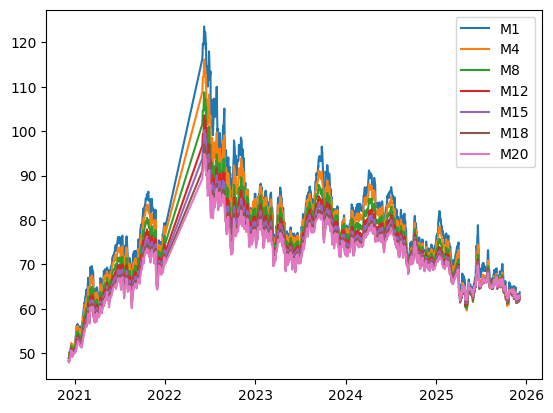

In [58]:
final_df_brent[["M1", "M4", "M8", "M12", "M15", "M18", "M20"]].plot()

<Axes: title={'center': 'Brent vols'}>

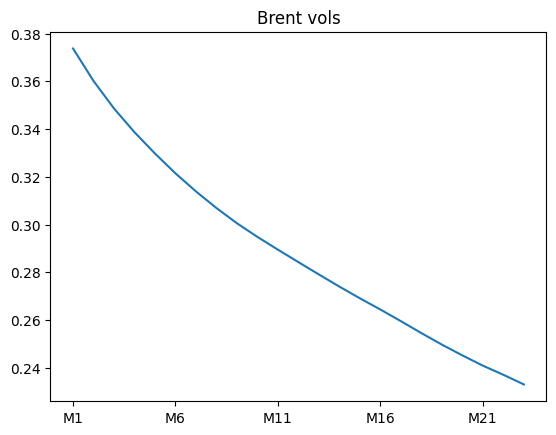

In [64]:
import numpy as np
df = final_df_brent
log_rets = np.log(df / df.shift(1)).dropna()
stds = log_rets.std() * np.sqrt(252)

corr_matrix = log_rets.corr()

stds.plot(title="Brent vols")


<Axes: title={'center': 'TTF vols'}>

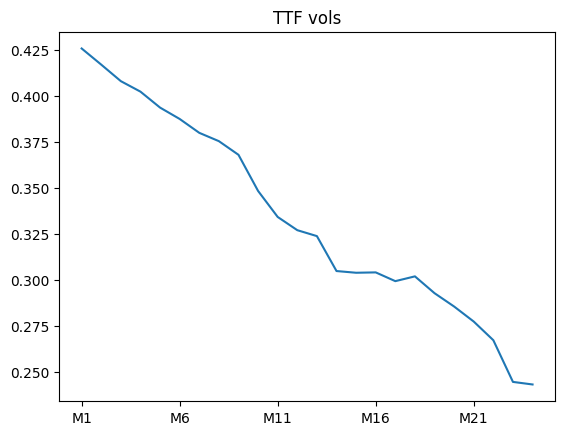

In [70]:
import numpy as np
df_ttf = final_df_ttf
log_rets_ttf = np.log(df_ttf / df_ttf.shift(1)).dropna()
stds = log_rets_ttf.std() * np.sqrt(252)

corr_matrix_ttf = log_rets_ttf.corr()

stds.plot(title="TTF vols")

In [ ]:
import seaborn as sns

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [26]:
import pandas as pd
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\BloombergData\\brent_freight_quotes_dec25.xlsx"
df = pd.read_excel(csv_file_path, index_col=0)

In [27]:
df_brent = df[["BrentM1"]]

cols_IKD = ["DatesIKDDec25"] + ["IKD"+m+"25" for m in ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]]
df_ikd = df[cols_IKD]
# df_ikd['DatesIKDDec25'] = pd.to_datetime(df_ikd['DatesIKDDec25'])
df_ikd = df_ikd.set_index('DatesIKDDec25').dropna(how='all')
# df_ikd.index = pd.to_datetime(df_ikd.index)

cols_LBE = ["DatesLBEDec25"] + ["LBE"+m+"25" for m in ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]]
df_lbe = df[cols_LBE]
# df_lbe['DatesIKDDec25'] = pd.to_datetime(df_ikd['DatesLBEDec25'])
df_lbe = df_lbe.set_index('DatesLBEDec25').dropna(how='all')
# df_lbe.index = pd.to_datetime(df_lbe.index)


In [32]:

monthly_avg = df_brent.resample("M").mean()
three_month_ma = monthly_avg.rolling(window=3, min_periods=3).mean()
brent301 = three_month_ma.shift(1)


C:\Users\marti.fernandezreal\AppData\Local\Temp\ipykernel_41932\989268521.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df_brent.resample("M").mean()


In [38]:
import numpy as np
logreturns_monthly = np.log(brent301.shift(1)/brent301).dropna()
yearly_std = logreturns_monthly.std() * np.sqrt(12)

In [39]:
yearly_std

BrentM1    0.136251
dtype: float64

In [4]:
import pandas as pd
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\BloombergData\\bbg_data_extractor.xlsx"
df = pd.read_excel(
    csv_file_path,
    sheet_name="HH_BBG",
    usecols="A:Y",
    skiprows=1,
    index_col=0)
df.index.name = None

In [52]:
import pandas as pd
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\BloombergData\\bbg_data_extractor.xlsx"
df_brent = pd.read_excel(
    csv_file_path,
    sheet_name="Brent_BBG",
    usecols="A:Y",
    skiprows=1,
    index_col=0)
df_brent.index.name = None

df_tfu = pd.read_excel(
    csv_file_path,
    sheet_name="TFU_BBG",
    usecols="A:Y",
    skiprows=1,
    index_col=0)
df_tfu.index.name = None

In [45]:
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\BloombergData\\bbg_data_extractor.xlsx"
df_jkm = pd.read_excel(
    csv_file_path,
    sheet_name="JKM_BBG",
    usecols="A:Y",
    skiprows=1,
    index_col=0)
df_jkm.index.name = None



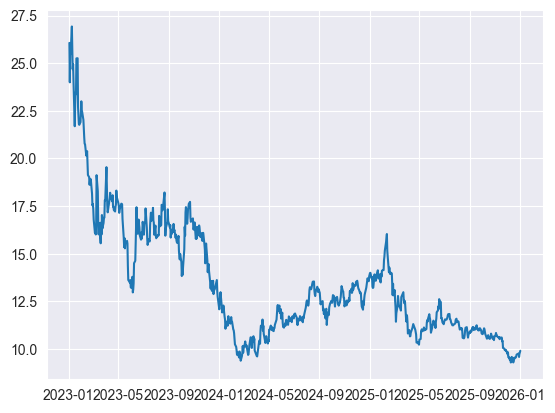

In [50]:
plt.plot(df_brent.index, df_brent.M12)

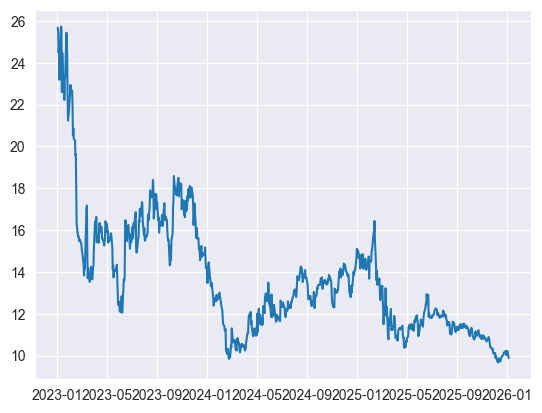

In [47]:
plt.plot(df_jkm.index, df_jkm.M12)

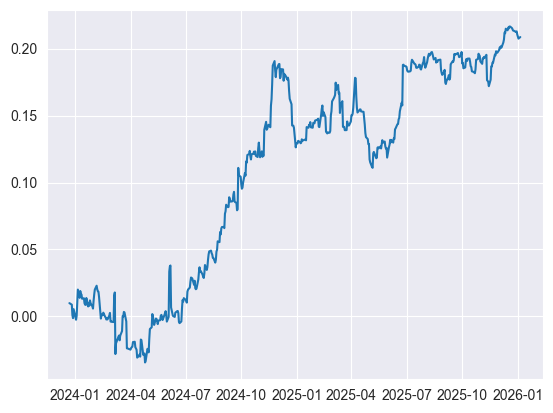

In [53]:
import numpy as np
import matplotlib.pyplot as plt
brent_series = df_brent.M12
# brent_series = df_tfu.M12
jkm_series = df_jkm.M12

logreturns_brent = np.log(brent_series/brent_series.shift(1))
logreturns_jkm = np.log(jkm_series/jkm_series.shift(1))

logreturns_brent.corr(logreturns_jkm)

common_dates = [d for d in logreturns_brent.index if d in logreturns_jkm.index]
corr_list = []
dates_list = []
for idx, d in enumerate(common_dates):
    if idx> 252:
        idx_dates = common_dates[idx-252:idx]
        brent_returns = logreturns_brent[idx_dates]
        jkm_returns = logreturns_jkm[idx_dates]
        corr_list.append(brent_returns.corr(jkm_returns))
        dates_list.append(d)
plt.plot(dates_list, corr_list)



In [43]:
brent_series.shift(0)

2024-01-02    74.00
2024-01-03    75.94
2024-01-04    75.08
2024-01-05    75.91
2024-01-08    73.79
              ...  
2025-12-29    60.89
2025-12-30    60.77
2025-12-31    60.23
2026-01-02    60.36
2026-01-05    60.53
Name: M11, Length: 519, dtype: float64

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def fit_and_plot_vols_for_underlying_df(df, und):
    log_rets = np.log(df / df.shift(1)).dropna()
    # ret = (df - df.shift(1)).dropna()
    stds = log_rets.std() * np.sqrt(365)

    mu0 = 0.4
    sigma0 = 0.3
    alpha0 = 1.0

    def error_func(params):
        p_mu, p_sigma, p_alpha = params
        _modelled_vols = np.array([(p_mu + p_sigma*(np.exp(-p_alpha*(15+30*i)/365))) for i in range(24)])
        value_error = sum((_modelled_vols - stds.values)**2)
        return value_error

    initial_guess = [mu0, sigma0, alpha0]
    bounds = [(0, 10.0), (0, 10.0), (0.5, 2.0)]
    result = minimize(error_func, initial_guess, bounds=bounds)

    mu, sigma, alpha = result.x
    modelled_vols = np.array([(mu + sigma*(np.exp(-alpha*(15+30*i)/365))) for i in range(24)])

    dates = stds.index
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dates, stds, color="navy", label="Series")
    ax.plot(dates, modelled_vols, color="green", label=f"Modelled Vols (mu, sigma, alpha)=({mu:.4f},{sigma:.4f},{alpha:.4f})")
    # ax.fill_between(dates, CIdown_stds, CIup_stds, color="skyblue", alpha=0.3, label="95% CI")
    ax.set_title(f"{und} vols: realised vs modelled")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True)
    return mu, sigma, alpha




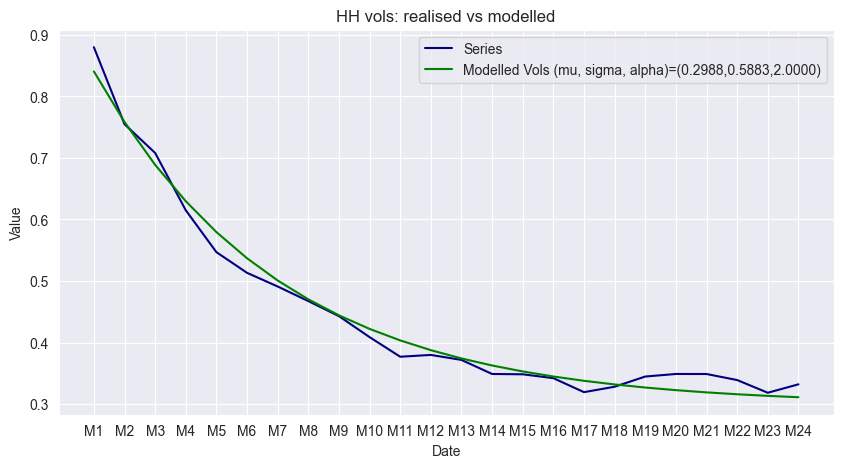

In [89]:
import pandas as pd
import seaborn as sns
import scipy
csv_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\BloombergData\\bbg_data_extractor.xlsx"

dict_result_vols = {}
for und in ["HH"]: #, "TFU", "JKM"]:
    df = pd.read_excel(
        csv_file_path,
        sheet_name=und+"_BBG",
        usecols="A:Y",
        skiprows=1,
        index_col=0)
    df.index.name = None

    _results = fit_and_plot_vols_for_underlying_df(df, und)
    dict_result_vols[und] = _results

    # # ret = (df - df.shift(1)).dropna()
    # ret = np.log(df / df.shift(1)).dropna()
    # # ret.hist(bins=30, figsize=(15, 10))
    # n_rows=5
    # n_cols=5
    # # Create the subplots
    # fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols)
    # # sns.distplot(ret, hist=True, kde=True,
    # #          bins=int(180/5), color = 'darkblue',
    # #          hist_kws={'edgecolor':'black'},
    # #          kde_kws={'linewidth': 4})
    # for i, column in enumerate(ret.columns):
    #     sns.distplot(ret[column],ax=axes[i//n_cols,i%n_cols])
    #     def map_pdf(x, **kwargs):
    #         mu, std = scipy.stats.norm.fit(x)
    #         x0, x1 = p1.axes[0][0].get_xlim()  # axes for p1 is required to determine x_pdf
    #         x_pdf = np.linspace(x0, x1, 100)
    #         y_pdf = scipy.stats.norm.pdf(x_pdf, mu, std)
    #         plt.plot(x_pdf, y_pdf, c='r')
    #
    #     p1 = sns.displot(data=ret, x=column, kind='hist', bins=40, stat='density')
    #     p1.map(map_pdf, column)



# print(dict_result_vols)


In [55]:
df_tfu = pd.read_excel(
        csv_file_path,
        sheet_name="TFU_BBG",
        usecols="A:Y",
        skiprows=1,
        index_col=0)

df_hh = pd.read_excel(
        csv_file_path,
        sheet_name="HH_BBG",
        usecols="A:Y",
        skiprows=1,
        index_col=0)


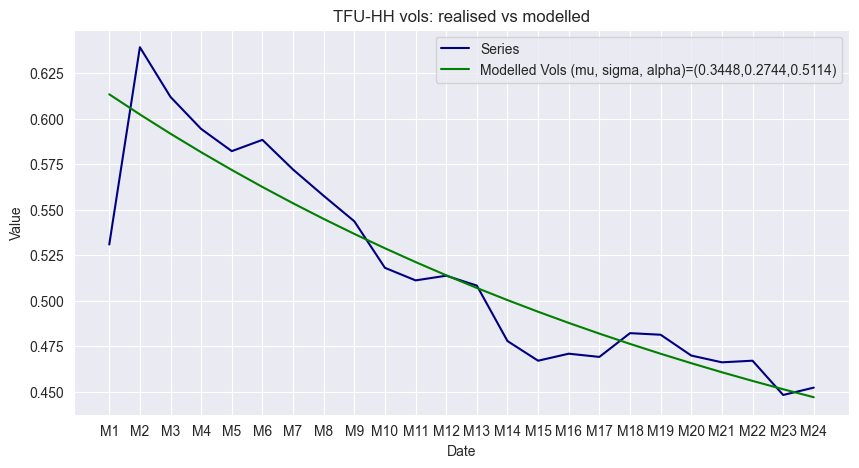

In [62]:

common_idx = df_hh.index.intersection(df_tfu.index)
common_cols = df_hh.columns.intersection(df_tfu.columns)

df_tfu_hh = df_tfu.loc[common_idx, common_cols] - df_hh.loc[common_idx, common_cols]

results_spread = fit_and_plot_vols_for_underlying_df(df_tfu_hh, und="TFU-HH")
